In [ ]:
!pip install albumentations

In [1]:
# 전체 패키지 체크
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import PIL
from PIL import Image
import albumentations
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import skimage
from skimage.io import imread
from skimage.transform import resize

print('=3')

=3


In [2]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [3]:
!python3 train_unet.py

[UNet] BATCH_SIZE=16, AMP=True, device=cuda
[UNet] Epoch 1/50 | train_loss=0.7008 train_dice=0.1576 | val_loss=0.6788 val_dice=0.0002
  -> best model saved (val_dice=0.0002) to ./checkpoints/unet_best.pth
[UNet] Epoch 2/50 | train_loss=0.6932 train_dice=0.0353 | val_loss=0.6575 val_dice=0.0000
[UNet] Epoch 3/50 | train_loss=0.6596 train_dice=0.0706 | val_loss=0.6252 val_dice=0.0000
[UNet] Epoch 4/50 | train_loss=0.5973 train_dice=0.1412 | val_loss=0.4966 val_dice=0.0000
[UNet] Epoch 5/50 | train_loss=0.5066 train_dice=0.1176 | val_loss=0.4505 val_dice=0.0000
[UNet] Epoch 6/50 | train_loss=0.4418 train_dice=0.4754 | val_loss=0.4113 val_dice=0.7407
  -> best model saved (val_dice=0.7407) to ./checkpoints/unet_best.pth
[UNet] Epoch 7/50 | train_loss=0.4339 train_dice=0.6531 | val_loss=0.2986 val_dice=0.7883
  -> best model saved (val_dice=0.7883) to ./checkpoints/unet_best.pth
[UNet] Epoch 8/50 | train_loss=0.4089 train_dice=0.6571 | val_loss=0.3000 val_dice=0.7497
[UNet] Epoch 9/50 | tra

In [4]:
# DEEP_SUPERVISION = True
!python3 train_unetpp.py

[UNet++] BATCH_SIZE=4, GRAD_ACCUM_STEPS=4 (effective batch=16), AMP=False, device=cuda
[UNet++] Epoch 1/50 | train_loss=0.6931 train_dice=0.0824 | val_loss=0.6700 val_dice=0.0000
  -> best model saved (val_dice=0.0000) to ./checkpoints/unetpp_best.pth
[UNet++] Epoch 2/50 | train_loss=0.6710 train_dice=0.0765 | val_loss=0.6438 val_dice=0.0000
[UNet++] Epoch 3/50 | train_loss=0.6265 train_dice=0.0765 | val_loss=0.6252 val_dice=0.0000
[UNet++] Epoch 4/50 | train_loss=0.5569 train_dice=0.0765 | val_loss=0.5131 val_dice=0.0000
[UNet++] Epoch 5/50 | train_loss=0.5103 train_dice=0.0824 | val_loss=0.4792 val_dice=0.0005
  -> best model saved (val_dice=0.0005) to ./checkpoints/unetpp_best.pth
[UNet++] Epoch 6/50 | train_loss=0.4705 train_dice=0.2549 | val_loss=0.4573 val_dice=0.7516
  -> best model saved (val_dice=0.7516) to ./checkpoints/unetpp_best.pth
[UNet++] Epoch 7/50 | train_loss=0.4378 train_dice=0.6468 | val_loss=0.4222 val_dice=0.6950
[UNet++] Epoch 8/50 | train_loss=0.3833 train_dice

In [9]:
!python3 inference_unet.py

[UNet] Loaded checkpoint: ./checkpoints/unet_best.pth (epoch=19, val_dice=0.8409)
[UNet] mIoU on labeled holdout (30 images): 0.7543
  Top-1: IoU=0.9295  image=000194_10.png -> ./inference_results/unet/top_k/top1_iou0.9295.png
  Top-2: IoU=0.9282  image=000190_10.png -> ./inference_results/unet/top_k/top2_iou0.9282.png
  Top-3: IoU=0.9239  image=000195_10.png -> ./inference_results/unet/top_k/top3_iou0.9239.png
[UNet] Saved 200 inference visualizations (no GT) to ./inference_results/unet/unlabeled_testing


In [10]:
!python3 inference_unetpp.py

[UNet++] Loaded checkpoint: ./checkpoints/unetpp_best.pth (epoch=33, val_dice=0.8082, deep_supervision=True)
[UNet++] mIoU on labeled holdout (30 images): 0.7299
  Top-1: IoU=0.9758  image=000185_10.png -> ./inference_results/unetpp/top_k/top1_iou0.9758.png
  Top-2: IoU=0.9745  image=000183_10.png -> ./inference_results/unetpp/top_k/top2_iou0.9745.png
  Top-3: IoU=0.9674  image=000181_10.png -> ./inference_results/unetpp/top_k/top3_iou0.9674.png
[UNet++] Saved 200 inference visualizations (no GT) to ./inference_results/unetpp/unlabeled_testing


In [7]:
!python3 visualize.py

Saved training curve plot to ./checkpoints/unet_training_curve.png
Figure(1200x400)
Saved training curve plot to ./checkpoints/unetpp_training_curve.png
Figure(1200x400)
Saved comparison plot to ./checkpoints/compare_val_dice.png
Figure(600x400)
Figure(2400x400)


# Semantic Segmentation 실험 방법 정리 (UNet vs UNet++)

## 1. 개요

KITTI semantic segmentation 데이터셋을 이용해 **UNet**과 **UNet++** 두 모델을 동일한 조건(입력 크기, loss, optimizer, epoch 등)에서 학습하고, held-out 평가셋과 실제 라벨 없는 testing set에 대해 추론 결과를 비교한다.

---

## 2. 데이터셋

### 2.1 데이터 구성

| 구분 | 경로 | 라벨 유무 | 용도 |
|---|---|---|---|
| Train / Val(holdout) | `~/work/semantic_segmentation/data/training` (`image_2/`, `semantic/`) | 있음 | 학습 및 검증 |
| Real Test | `~/work/semantic_segmentation/data/testing` (`images_2/`) | **없음** | 정성적 추론(시각화)만 가능 |

- `training` 폴더의 전체 쌍(이미지-라벨) 중 **마지막 30장을 holdout(test_dataset)**으로 분리하여 학습 중 검증 및 최종 정량 평가(mIoU)에 사용한다.
- `testing` 폴더는 `images_2/`만 존재하고 정답 라벨이 없어 **IoU/mIoU 계산이 불가능**하다. 따라서 이 데이터는 순수 추론(오버레이 시각화) 결과 확인 용도로만 사용한다.

### 2.2 라벨 정의

- KITTI semantic 라벨 중 특정 클래스 값(`== 7`, 도로(road) 클래스)만 이진 마스크(0/1)로 변환하여 사용한다.
- 즉 본 실험은 **다중 클래스 분할이 아닌, 단일 클래스(도로) 이진 분할** 문제로 설정되어 있다.

### 2.3 전처리 및 Augmentation (`albumentations`)

| 구분 | 적용 기법 |
|---|---|
| Train | `HorizontalFlip(p=0.5)` → `RandomSizedCrop(min_max_height=(300,370), size=(224,224), p=0.5)` → `Resize(224,224)` |
| Test / Val | `Resize(224,224)`만 적용 |

- 이미지는 `/255.0`으로 정규화 후 `(H,W,C) → (C,H,W)`로 변환하여 텐서화한다.
- 마스크는 이미지와 동일한 geometric transform이 적용되며, 채널 차원을 `(1,H,W)`로 확장한다.
- 매 epoch 종료 시 `KittiDataset.shuffle_data()`를 호출하여 학습 데이터 순서를 셔플한다.

---

## 3. 모델 구조

| 항목 | UNet | UNet++ |
|---|---|---|
| Encoder depth | 4 (64→128→256→512→1024) | 4 (동일, `base_filters=64`) |
| Skip connection | 동일 depth의 encoder ↔ decoder 1:1 연결 | Dense skip pathway (`X_i,j`) — 여러 depth의 중간 노드를 재사용해 촘촘하게 연결 |
| Upsampling | `ConvTranspose2d` (학습 가능한 up-conv) | `bilinear Upsample` (원 논문 방식) |
| Bottleneck Dropout | 0.5 | 0.5 (동일 위치) |
| Deep Supervision | 해당 없음 | 지원(옵션, 기본 `False`로 UNet과 공정 비교) |
| 출력 | `Conv1x1 → Sigmoid` (단일 채널 확률맵) | 동일 |

두 모델 모두 `input_channels=3`, `output_channels=1`(도로 클래스 확률)로 설정하여 구조적 차이(dense skip / upsampling 방식) 외 변수를 통제했다.

---

## 4. 학습 설정

| 항목 | 값 |
|---|---|
| Batch size | 16 |
| Epochs | 50 |
| Optimizer | Adam, lr=1e-4 |
| LR Scheduler | `ReduceLROnPlateau` (mode='max', factor=0.5, patience=5, val_dice 기준) |
| Loss (Criterion) | `BCEDiceLoss` = 0.5×BCE + 0.5×SoftDiceLoss |
| 평가 지표 | Dice Coefficient (threshold=0.5 이진화 후 계산) |
| Device | CUDA 가능 시 GPU, 아니면 CPU |

### 4.1 Loss 설계 근거

- **BCE**: 픽셀 단위 분류 오차를 직접 최소화하지만 클래스 불균형(도로 vs 배경)에 취약할 수 있음.
- **Dice Loss**: 예측 영역과 정답 영역의 겹침 비율을 직접 최적화하여 클래스 불균형에 강건함.
- 두 손실을 절반씩 결합해 픽셀 단위 정밀도와 영역 겹침을 동시에 고려하도록 구성했다.
- 평가 시 사용하는 **Dice Coefficient**는 loss와 달리 미분 가능성을 고려할 필요가 없으므로 0.5 threshold로 이진화한 뒤 계산해 실제 성능을 직관적으로 나타낸다.

### 4.2 체크포인트 저장

- 매 epoch 종료 시 `*_last.pth` 저장 (재학습 재개용, `model/optimizer state_dict`, `epoch`, `val_dice` 포함)
- validation Dice가 갱신될 때마다 `*_best.pth` 저장
- 학습 종료 후 epoch별 `train_loss/train_dice/val_loss/val_dice`를 `*_history.json`으로 저장하여 이후 시각화에 사용

---

## 5. 추론 및 평가 방법

### 5.1 정량 평가 (mIoU)

- 라벨이 존재하는 **holdout set(`test_dataset`, 30장)**을 대상으로 이미지별 추론을 수행한다.
- 각 이미지에 대해 예측 마스크(0.5 threshold 이진화)와 정답 마스크 간 IoU를 계산한다.

  ```
  IoU = |prediction ∩ target| / |prediction ∪ target|
  ```

- 전체 holdout 이미지의 IoU 평균을 **mIoU**로 산출하여 모델 성능을 정량적으로 비교한다.
- 새로 제공된 실제 `testing/images_2`는 라벨이 없어 이 정량 평가에는 포함하지 않는다(구조적으로 IoU 계산 불가능).

### 5.2 정성 평가 (시각화)

- holdout set 중 **IoU가 가장 높은 상위 3개 이미지**를 선정하여, 원본 이미지와 예측 마스크를 반투명하게 합성(`alpha=0.5`)한 오버레이 이미지를 저장한다.
- 라벨이 없는 실제 `testing/images_2`에 대해서도 동일한 방식으로 오버레이 이미지를 생성하되, IoU 계산 없이 **정성적 확인 용도**로만 저장한다.

### 5.3 결과 저장 구조 (모델별 동일)

```
inference_results/{unet|unetpp}/
├── labeled_eval/        # holdout 전체 이미지 오버레이 결과
├── top_k/               # IoU 상위 3개 오버레이 결과 (파일명에 IoU 값 포함)
├── unlabeled_testing/   # 라벨 없는 실제 testing set 추론 결과 (IoU 없음)
└── miou_result.json     # {model, miou, num_samples}
```

---

## 6. 결과 비교 및 시각화

`visualize.py`를 통해 다음을 확인한다.

1. **`plot_training_curves`**: 모델별 epoch에 따른 train/val loss, train/val dice 곡선 → 과적합 여부 및 수렴 여부 확인
2. **`compare_models_curves`**: UNet vs UNet++의 `val_dice`(또는 원하는 지표)를 한 그래프에서 비교
3. **`show_topk_images`**: 각 모델의 IoU 상위 3개 오버레이 결과를 나란히 비교

---

## 7. 실행 순서 요약

```
1) python train_unet.py        # UNet 학습 → checkpoints/unet_best.pth, unet_history.json
2) python train_unetpp.py      # UNet++ 학습 → checkpoints/unetpp_best.pth, unetpp_history.json
3) python inference_unet.py    # UNet 추론 → mIoU 출력, top-3 저장, 라벨 없는 set 추론
4) python inference_unetpp.py  # UNet++ 추론 → 동일
5) python visualize.py         # 학습 곡선 및 top-3 결과 비교 시각화
```

---

## 8. 실험 시 주의사항 / 한계

- 본 실험은 **단일 클래스(도로) 이진 분할**로 한정되어 있어, "mIoU"는 다중 클래스 평균이 아닌 **단일 클래스 IoU의 이미지 간 평균**을 의미한다.
- 라벨이 없는 실제 `testing/images_2`에 대한 정량적 성능(mIoU)은 확인할 수 없으며, holdout(training 폴더 마지막 30장) 기준 성능이 실제 testing 성능을 완전히 대변하지 않을 수 있다.
- UNet은 `ConvTranspose2d`, UNet++는 `bilinear Upsample`을 사용해 upsampling 방식이 다르므로, 두 모델의 성능 차이가 dense skip 구조뿐 아니라 upsampling 방식 차이에서도 기인할 수 있다는 점을 고려해야 한다.

# 실험 내용
---
1. AMP 적용 및 Deep supervision 미적용 비교
- trainset에서 추출한 holdout set inference 결과 iou top1 비교 (UNet++(위), UNet(아래))

  unet은 가장 결과가 좋은 케이스도 도로를 매끄럽게 잡아내지 못한 반면 UNet++는 어느정도 매끄럽게 잡아냄

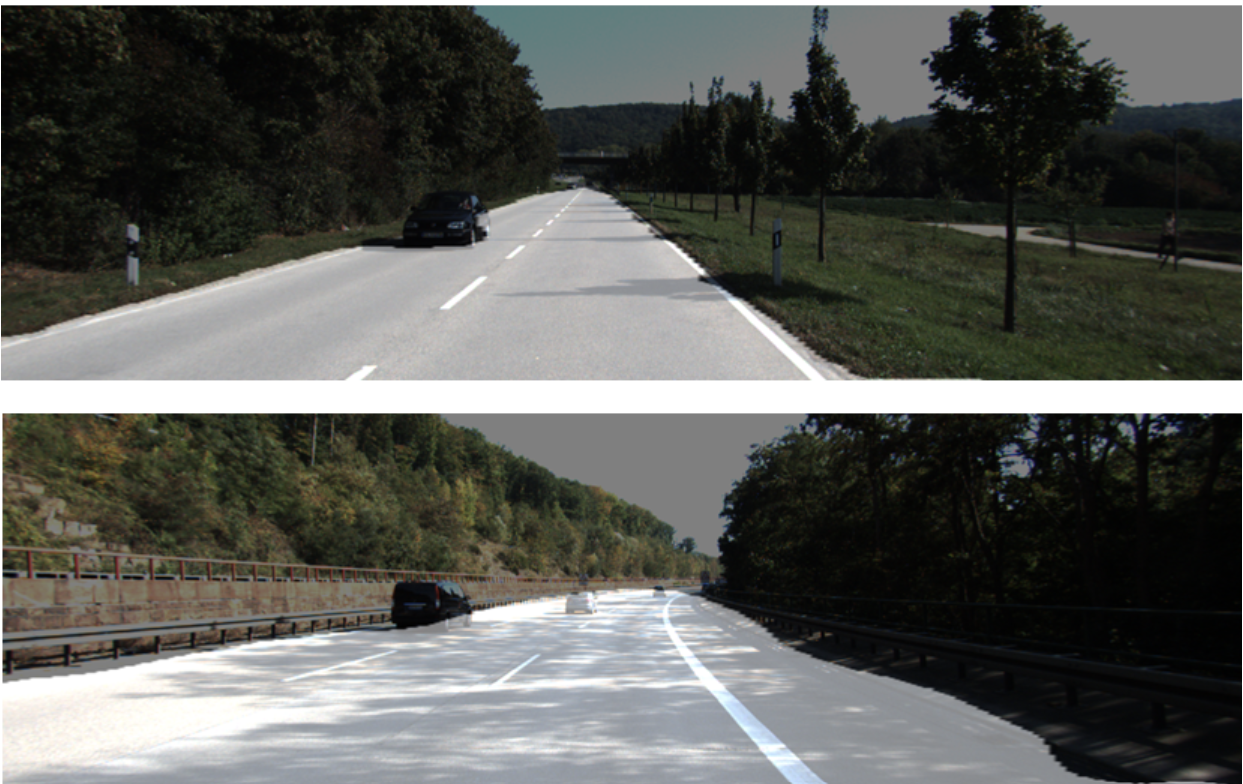

- miou 수치는 UNet "miou": 0.7595 , UNet++ "miou": 0.7506 으로 오히려 UNet이 높았음. 정량 평가에 사용된 데이터가 30장으로 매우 적어 유의미한 결과인지 판단하기 어려움
- validation loss 그래프 확인한 결과 UNet++ 학습 과정에서 loss 가 폭발적으로 발산해버리는 문제가 있었음
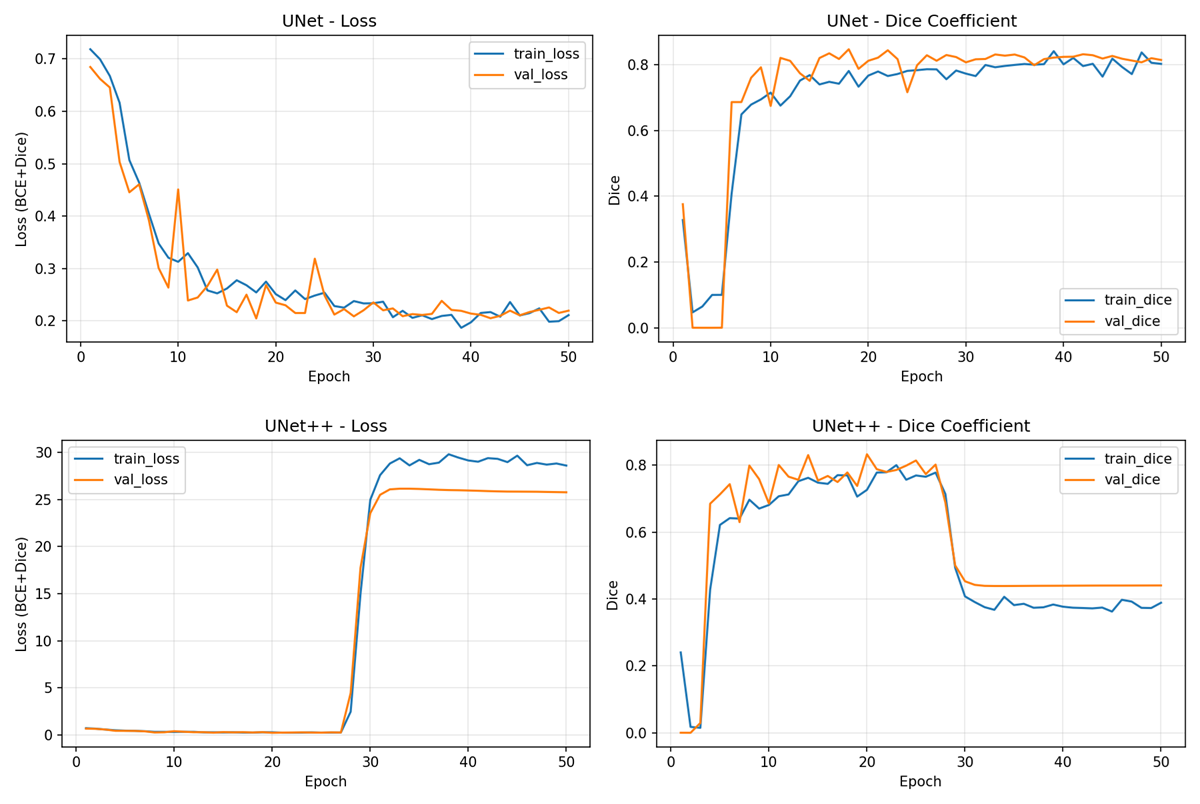

- 발산 원인 분석
  1. 초기 UNet forward 구조 (sigmoid사용)에 맞춰서 UNet++도 sigmoid 사용하는 형태로 구현 -> logit 반환 형태가 아니라서 BCEWithLogitsLoss 가 아닌 BCELoss를 사용함 -> sigmoid+BCE 조합이 구성되면서 확률이 정확히 0/1이 되면 gradient가 1/0이 되는 수학적 결함 발생
  2. 자원 절약을 위해 AMP를 사용하면서, sigmoid 결과가 0또는 1로 쉽게 반올림됨
     (fp16 정밀도: logit이 겨우 ~7.6만 넘어도 확률이 "거의 1"이 아니라 "정확히 1"로 반올림됨)
  3. Batch Normalization 구조 미사용 -> logit이 블록마다 정규화 되지 않아서 7.6 도달 가능해짐
  4. Optimizer를 Adam 사용 -> momentum 으로 인해 한번만 gradient가 inf 떠버리면 매우 오랫동안 기억해버림 (발산이 유지되어버림)
  5. ReLU 사용 -> ReLU 특유의 "죽은 뉴런(dying ReLU)" 현상 발생.
     가중치가 한 번 크게 밀리면서 특정 채널들의 pre-activation이 항상 음수가 되어버리면, ReLU 출력이 영원히 0이 되고 gradient도 더 이상 흐르지 못함.
     그래프에서 collapse 직후 val_dice가 0.44에서 평평하게 고정됨


- 해결 방안 적용
  1. pred clamp 적용하여 log(0) 차단
  2. AMP 미사용 (전체 fp32 사용)
  4. gradient cliping 적용하여 큰 gradient가 momentum에 못들어가게 차단
- 개선한 후 학습 결과
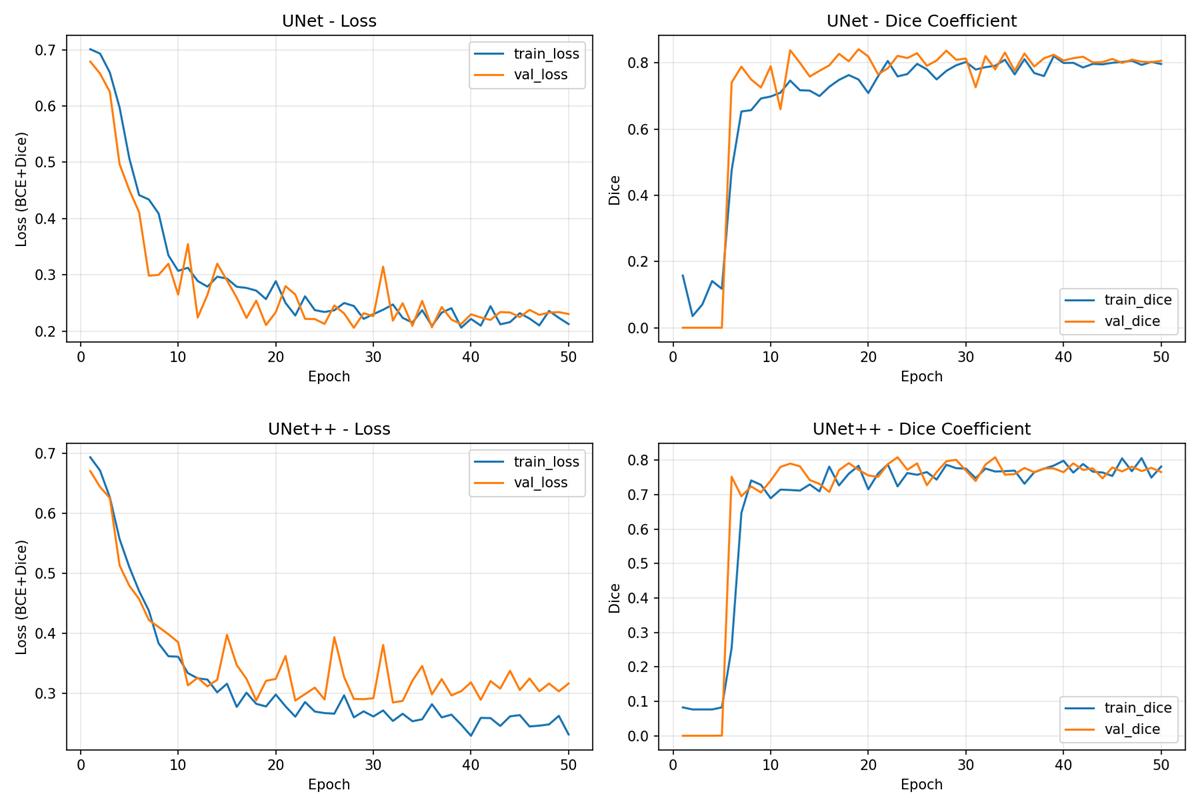

- 같은 조건에서 UNet은 발산되지 않은 이유?
  BN이 없는 상태에서 UNet++는 여러 채널 특징 맵을 concat 하는 구조로 인해 UNet보다 스케일이 커질 여지가 큼
  즉 여러 겹의 conv+ReLU를 거쳐 나온 값이라, 채널 방향으로 값의 스케일이 계속 누적/증폭될 여지가 UNet(단순히 같은 depth 1개만 concat)보다 크다
  UNet은 운좋게 값이 매우 커지는 상황이 발생하지 않았던 것으로 추정된다
  
2. AMP 미적용 및 Deep supervision 적용 비교
- holdout set iou top1 비교(UNet(위), UNet++(아래))
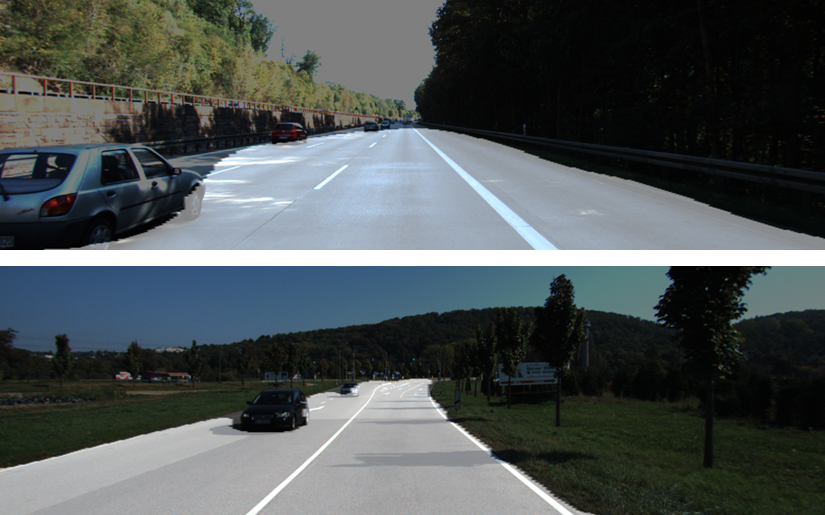

- holdout set 동일 이미지 비교 (UNet(위), UNet++(아래))
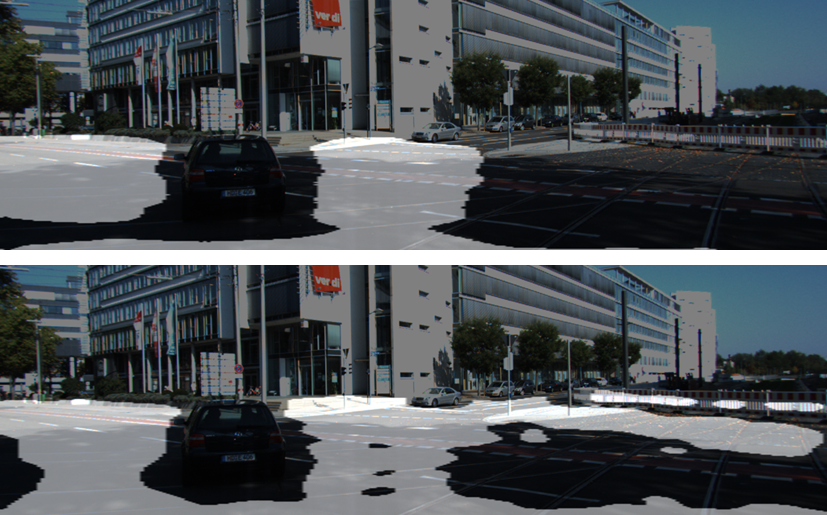
- mIoU 는 격차가 더 벌어짐
- UNet: mIoU 0.7542
- UNet++: mIoU 0.7298

deep supervision을 켰음에도 오히려 격차가 벌어진 원인 추정:
   1. 데이터셋이 작아서 UNet++가 상대적으로 과적합했을 수 있음
   2. UNet은 학습 가능한 ConvTranspose2d로 업샘플링, UNet++는 파라미터 없는 bilinear Upsample을 써서 경계(edge) 복원력이 UNet보다 떨어졌을 수 있음
    

## 결론
정성 평가에서는 상위 예측 결과를 보면 UNet++가 확실히 더 매끄럽고 성능이 좋아보였음
정량 평가에서는 오히려 UNet이 조금 더 좋았음

이번 실험 조건에서는 고점은 UNet++가 높고 저점은 UNet이 높은 것으로 보임